In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0
    controlVariable_StockUpperLimit: float = 60000.5  # Default to no deadband
    controlVariable_StockLowerLimit: float = 59999.5  # Default to no deadband

    # --- FIXES ---
    parameter_ExtractionGain: float = 0.0
    enable_feed_control: bool = False


# Initialize parameters
mining_params = MiningParameters()

In [2]:
# Constants for easier reading
total_mill_A = "(parameter_ModeAOre1MillingRate + parameter_ModeAOre2MillingRate)"
total_mill_B = "(parameter_ModeBOre1MillingRate + parameter_ModeBOre2MillingRate)"

# Independent swappable components for extraction logic
extraction_A_normal = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_A} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

extraction_A_contingency = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeAContingencyOre1MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

arena_config = {
    "confExString_TerminatingCondition": "OreExtraction_Level >= parameter_TotalOreToBeExtracted",
    "confExString_InitialRateConfigurationNumber": "1",
    "confExString_InitialLevelValue": ["0", "0", "60000", "42000", "18000"],
    "confExString_InitialTimerValue": ["0"] * 9,
    "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
        "40000",
        "30",
        "1",
    ],
    "confExString_InitialCategoricalVariableValue": [""],
    "confExString_LevelRate": [
        # Level 0 (Extraction)
        [
            extraction_A_normal,
            extraction_A_contingency,  # PERFECT MATCH: Mine tracks contingency rate
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 1 (Parcel Progress)
        [
            extraction_A_normal,
            extraction_A_contingency,
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 2 (Total Stock)
        [
            f"{extraction_A_normal} - {total_mill_A}",
            f"{extraction_A_contingency} - parameter_ModeAContingencyOre1MillingRate",  # Net 0 when Gain=0
            f"(parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)) - {total_mill_A}",
            "0",
            f"parameter_ModeBContingencyOre2MillingRate - {total_mill_B}",
            f"(parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel) - {total_mill_B}",
            "0",
        ],
        # Level 3 (Ore 1)
        [
            f"{extraction_A_normal}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
            f"{extraction_A_contingency}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",  # Net 0 when Gain=0
            "0",
            f"{total_mill_B}*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
            "parameter_ModeBContingencyOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/100",
            "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
            "0",
        ],
        # Level 4 (Ore 2)
        [
            f"{extraction_A_normal}*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
            f"{extraction_A_contingency}*(PercentageOfOre2InCurrentParcel/100)",  # Net 0 when Gain=0
            f"parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
            f"{total_mill_B}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
            f"parameter_ModeBContingencyOre2MillingRate*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
            "0",
            "0",
        ],
    ],
    "confExString_LowerLevelThreshold": [
        ["-999999"] * 7,
        ["-999999"] * 7,
        [
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
        ],
        ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
        ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
    ],
    "confExString_UpperLevelThreshold": [
        ["parameter_TotalOreToBeExtracted"] * 7,
        ["MassOfCurrentParcel"] * 6 + ["999999"],
        ["controlVariable_StockUpperLimit"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    "confExString_LowerLevelResultantRateConfiguration": [
        ["0"] * 7,
        ["0"] * 7,
        ["0", "0", "1", "0", "0", "4", "0"],
        ["3", "3", "0", "5", "0", "0", "0"],
        ["2", "0", "0", "6", "6", "0", "0"],
    ],
    "confExString_UpperLevelResultantRateConfiguration": [
        ["1", "2", "3", "4", "5", "6", "0"],
        ["1", "2", "3", "4", "5", "6", "0"],
        ["0", "0", "7", "0", "0", "7", "0"],
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerLevelAssignmentAddress": [["0"] * 7 for _ in range(5)],
    "confExString_UpperLevelAssignmentAddress": [
        ["0"] * 7,
        ["4"] * 6 + ["0"],  # CRITICAL FIX: Reverted to 4 so parcels generate
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_TimerRate": [
        ["1"] * 7,
        ["0", "1", "0", "0", "1", "0", "0"],
        ["1", "0", "0", "0", "0", "0", "0"],
        ["0", "1", "0", "0", "0", "0", "0"],
        ["0", "0", "1", "0", "0", "0", "0"],
        ["0", "0", "0", "1", "0", "0", "0"],
        ["0", "0", "0", "0", "1", "0", "0"],
        ["0", "0", "0", "0", "0", "1", "0"],
        ["0", "0", "0", "0", "0", "0", "1"],
    ],
    "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
    "confExString_UpperTimerThreshold": [
        ["parameter_DurationOfProductionCampaigns"] * 6
        + ["parameter_DurationOfShutdowns"],
        [
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
        ],
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    "confExString_UpperTimerResultantRateConfiguration": [
        [
            "7",
            "7",
            "7",
            "7",
            "7",
            "7",
            "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*6",
        ],
        ["0", "1", "0", "0", "4", "0", "0"],
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_UpperTimerAssignmentAddress": [
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
    "confExString_AssignmentSequence": [
        ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],
        ["T001:0", "", "", "", "", "", ""],
        ["T002:0", "", "", "", "", "", ""],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:parameterVector_GeostatisticalModelParameters(4)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
    ],
}

Initializing Framework...
Starting simulation loop...
Iteration 100: TNOW = 489.56
Iteration 200: TNOW = 1007.69
Simulation terminated successfully at TNOW: 1188.30 days.
Execution Time: 0.4444 seconds.

--- Final Simulation Statistics ---
Total Throughput:             5,554.14 t/day
Time in Mode A:               54.50%
Time in Mode B:               36.86%
Time in Shutdown:             2.78%
Time in Mode A Contingency:   2.67%
Time in Mode B Contingency:   0.00%
-----------------------------------


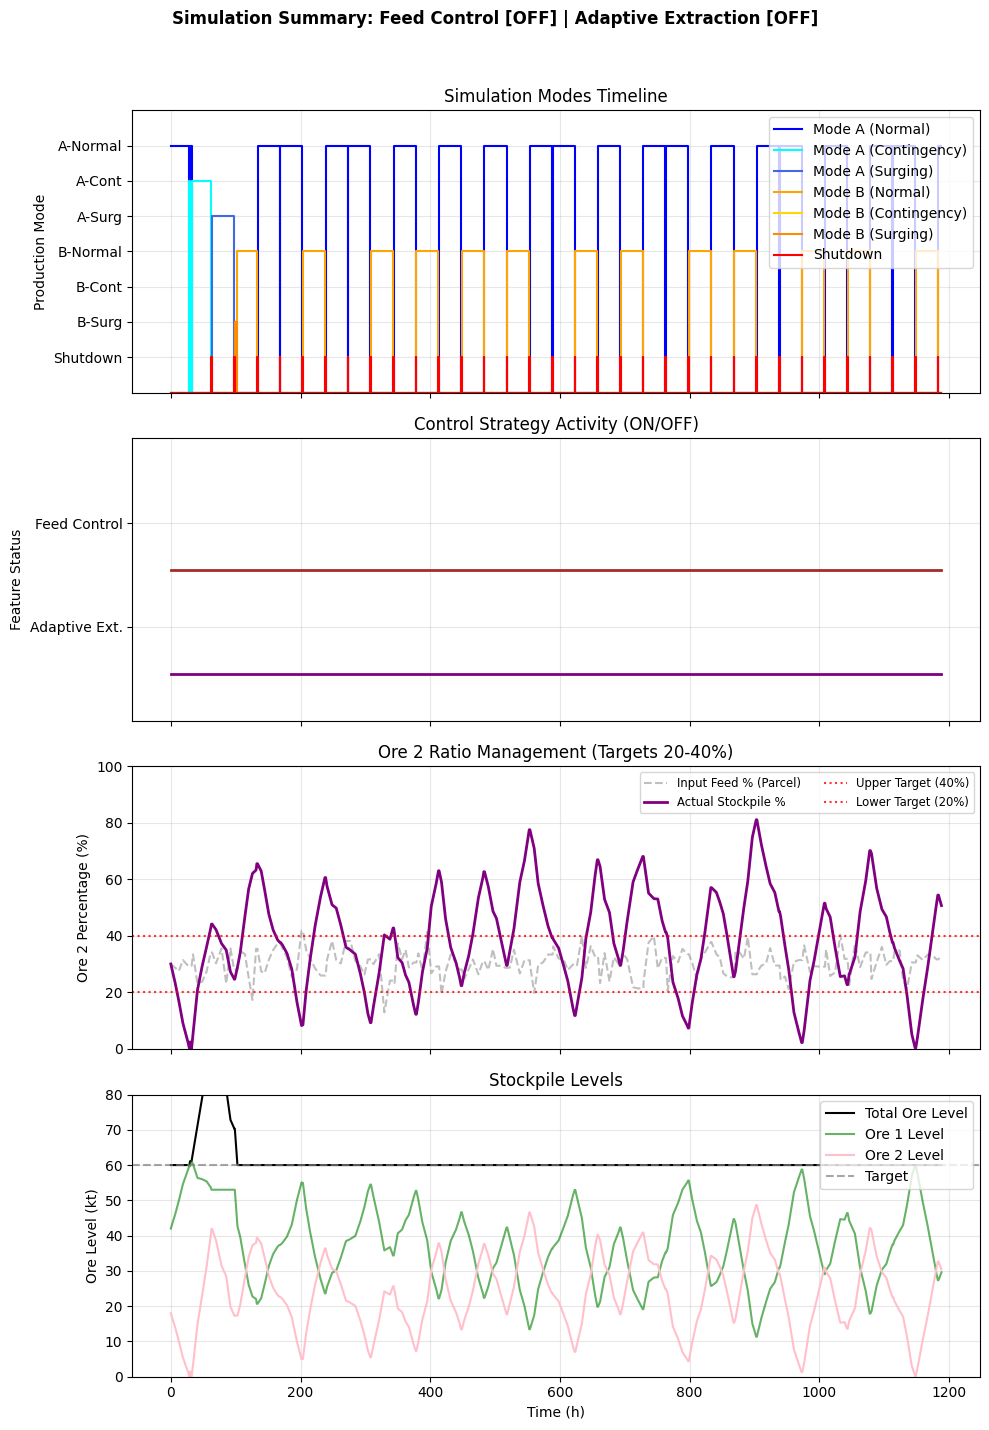

In [3]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0
    controlVariable_StockUpperLimit: float = 60000.5  # Default to no deadband
    controlVariable_StockLowerLimit: float = 59999.5  # Default to no deadband

    # --- FIXES ---
    parameter_ExtractionGain: float = 0.01
    enable_feed_control: bool = True


# Initialize parameters
mining_params = MiningParameters()

Initializing Framework...
Starting simulation loop...
Iteration 100: TNOW = 517.35
Iteration 200: TNOW = 1023.54
Simulation terminated successfully at TNOW: 1191.80 days.
Execution Time: 0.4275 seconds.

--- Final Simulation Statistics ---
Total Throughput:             5,537.84 t/day
Time in Mode A:               48.65%
Time in Mode B:               48.50%
Time in Shutdown:             2.85%
Time in Mode A Contingency:   0.00%
Time in Mode B Contingency:   0.00%
-----------------------------------


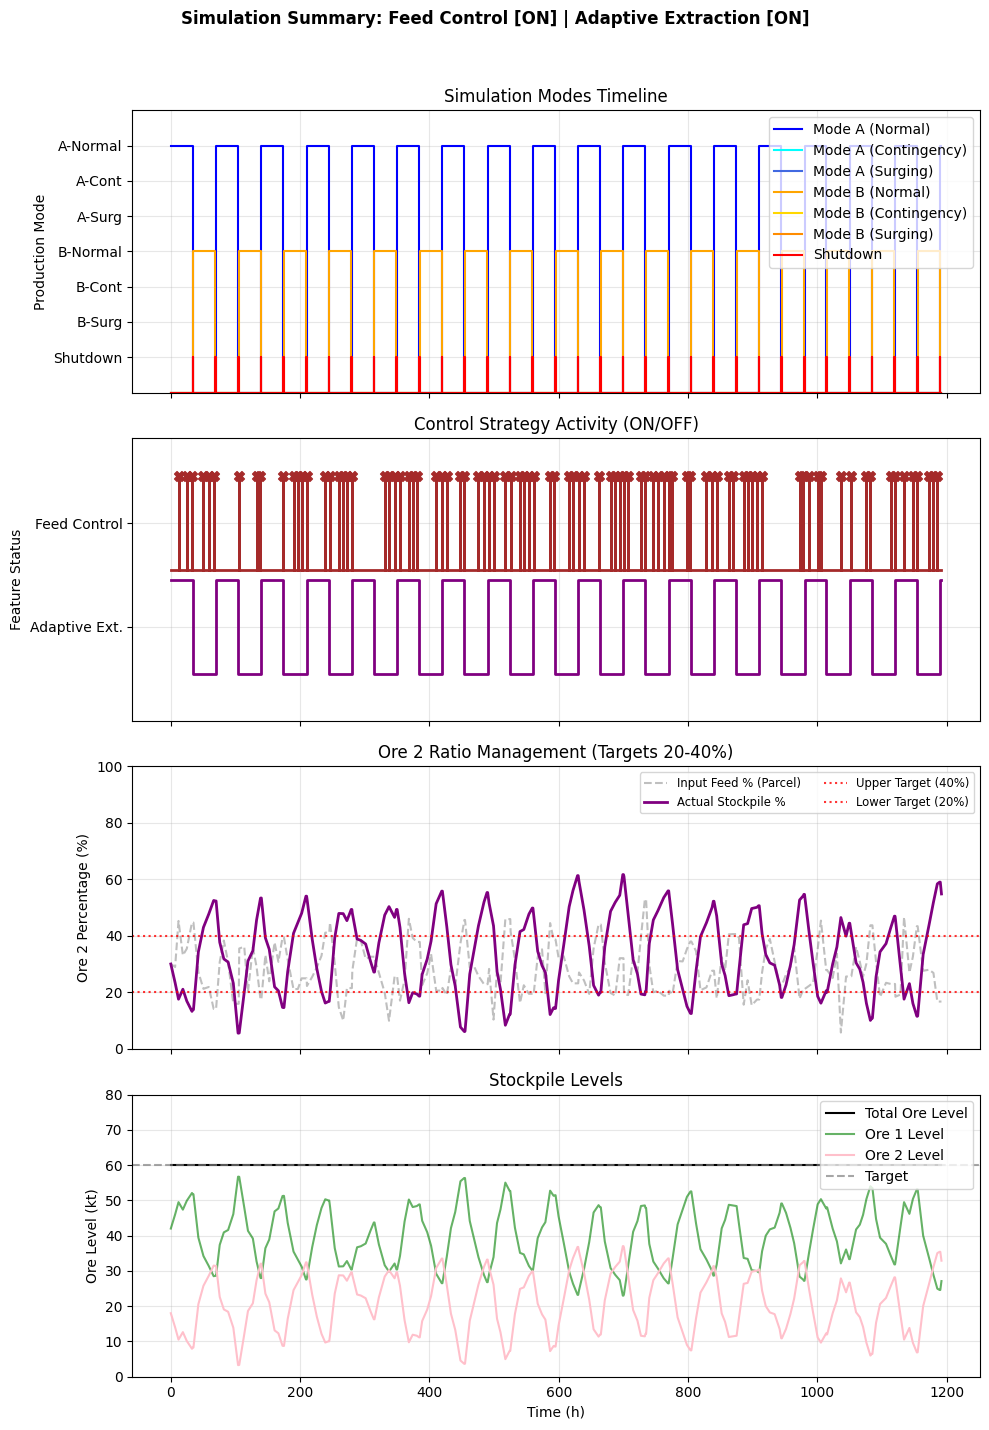

In [5]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0
    controlVariable_StockUpperLimit: float = 60000.5  # Default to no deadband
    controlVariable_StockLowerLimit: float = 59999.5  # Default to no deadband

    # --- FIXES ---
    parameter_ExtractionGain: float = 0.0
    enable_feed_control: bool = False


# Initialize parameters
mining_params = MiningParameters()


# Initialize parameters
mining_params = MiningParameters()

In [7]:
# Constants for easier reading
total_mill_A = "(parameter_ModeAOre1MillingRate + parameter_ModeAOre2MillingRate)"
total_mill_B = "(parameter_ModeBOre1MillingRate + parameter_ModeBOre2MillingRate)"

# Independent swappable components for extraction logic
extraction_A_normal = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_A} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

extraction_A_contingency = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeAContingencyOre1MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

arena_config = {
    "confExString_TerminatingCondition": "OreExtraction_Level >= parameter_TotalOreToBeExtracted",
    "confExString_InitialRateConfigurationNumber": "1",
    "confExString_InitialLevelValue": ["0", "0", "30000", "42000", "18000"],
    "confExString_InitialTimerValue": ["0"] * 9,
    "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
        "40000",
        "30",
        "1",
    ],
    "confExString_InitialCategoricalVariableValue": [""],
    "confExString_LevelRate": [
        # Level 0 (Extraction)
        [
            extraction_A_normal,
            extraction_A_contingency,  # PERFECT MATCH: Mine tracks contingency rate
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 1 (Parcel Progress)
        [
            extraction_A_normal,
            extraction_A_contingency,
            "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
            total_mill_B,
            "parameter_ModeBContingencyOre2MillingRate",
            "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
            "0",
        ],
        # Level 2 (Total Stock)
        [
            f"{extraction_A_normal} - {total_mill_A}",
            f"{extraction_A_contingency} - parameter_ModeAContingencyOre1MillingRate",  # Net 0 when Gain=0
            f"(parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)) - {total_mill_A}",
            "0",
            f"parameter_ModeBContingencyOre2MillingRate - {total_mill_B}",
            f"(parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel) - {total_mill_B}",
            "0",
        ],
        # Level 3 (Ore 1)
        [
            f"{extraction_A_normal}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
            f"{extraction_A_contingency}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",  # Net 0 when Gain=0
            "0",
            f"{total_mill_B}*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
            "parameter_ModeBContingencyOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/100",
            "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
            "0",
        ],
        # Level 4 (Ore 2)
        [
            f"{extraction_A_normal}*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
            f"{extraction_A_contingency}*(PercentageOfOre2InCurrentParcel/100)",  # Net 0 when Gain=0
            f"parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
            f"{total_mill_B}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
            f"parameter_ModeBContingencyOre2MillingRate*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
            "0",
            "0",
        ],
    ],
    "confExString_LowerLevelThreshold": [
        ["-999999"] * 7,
        ["-999999"] * 7,
        [
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
            "-999999",
            "controlVariable_StockLowerLimit",
            "-999999",
        ],
        ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
        ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
    ],
    "confExString_UpperLevelThreshold": [
        ["parameter_TotalOreToBeExtracted"] * 7,
        ["MassOfCurrentParcel"] * 6 + ["999999"],
        ["controlVariable_StockUpperLimit"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    "confExString_LowerLevelResultantRateConfiguration": [
        ["0"] * 7,
        ["0"] * 7,
        ["0", "0", "1", "0", "0", "4", "0"],
        ["3", "3", "0", "5", "0", "0", "0"],
        ["2", "0", "0", "6", "6", "0", "0"],
    ],
    "confExString_UpperLevelResultantRateConfiguration": [
        ["1", "2", "3", "4", "5", "6", "0"],
        ["1", "2", "3", "4", "5", "6", "0"],
        ["0", "0", "7", "0", "0", "7", "0"],
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerLevelAssignmentAddress": [["0"] * 7 for _ in range(5)],
    "confExString_UpperLevelAssignmentAddress": [
        ["0"] * 7,
        ["4"] * 6 + ["0"],  # CRITICAL FIX: Reverted to 4 so parcels generate
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_TimerRate": [
        ["1"] * 7,
        ["0", "1", "0", "0", "1", "0", "0"],
        ["1", "0", "0", "0", "0", "0", "0"],
        ["0", "1", "0", "0", "0", "0", "0"],
        ["0", "0", "1", "0", "0", "0", "0"],
        ["0", "0", "0", "1", "0", "0", "0"],
        ["0", "0", "0", "0", "1", "0", "0"],
        ["0", "0", "0", "0", "0", "1", "0"],
        ["0", "0", "0", "0", "0", "0", "1"],
    ],
    "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
    "confExString_UpperTimerThreshold": [
        ["parameter_DurationOfProductionCampaigns"] * 6
        + ["parameter_DurationOfShutdowns"],
        [
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
            "controlVariable_DurationOfContingencySegments",
            "999999",
            "999999",
        ],
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
        ["999999"] * 7,
    ],
    "confExString_UpperTimerResultantRateConfiguration": [
        [
            "7",
            "7",
            "7",
            "7",
            "7",
            "7",
            "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*6",
        ],
        ["0", "1", "0", "0", "4", "0", "0"],
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_UpperTimerAssignmentAddress": [
        ["2"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
        ["0"] * 7,
    ],
    "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
    "confExString_AssignmentSequence": [
        ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],
        ["T001:0", "", "", "", "", "", ""],
        ["T002:0", "", "", "", "", "", ""],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:parameterVector_GeostatisticalModelParameters(4)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
        [
            "L002:0",
            "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
            "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
            "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
            "E001:1",
            "",
            "",
        ],
    ],
}

Initializing Framework...
Starting simulation loop...
Iteration 100: TNOW = 517.26
Iteration 200: TNOW = 1006.28
Simulation terminated successfully at TNOW: 1181.90 days.
Execution Time: 0.4471 seconds.

--- Final Simulation Statistics ---
Total Throughput:             5,584.25 t/day
Time in Mode A:               56.28%
Time in Mode B:               40.27%
Time in Shutdown:             2.79%
Time in Mode A Contingency:   0.66%
Time in Mode B Contingency:   0.00%
-----------------------------------


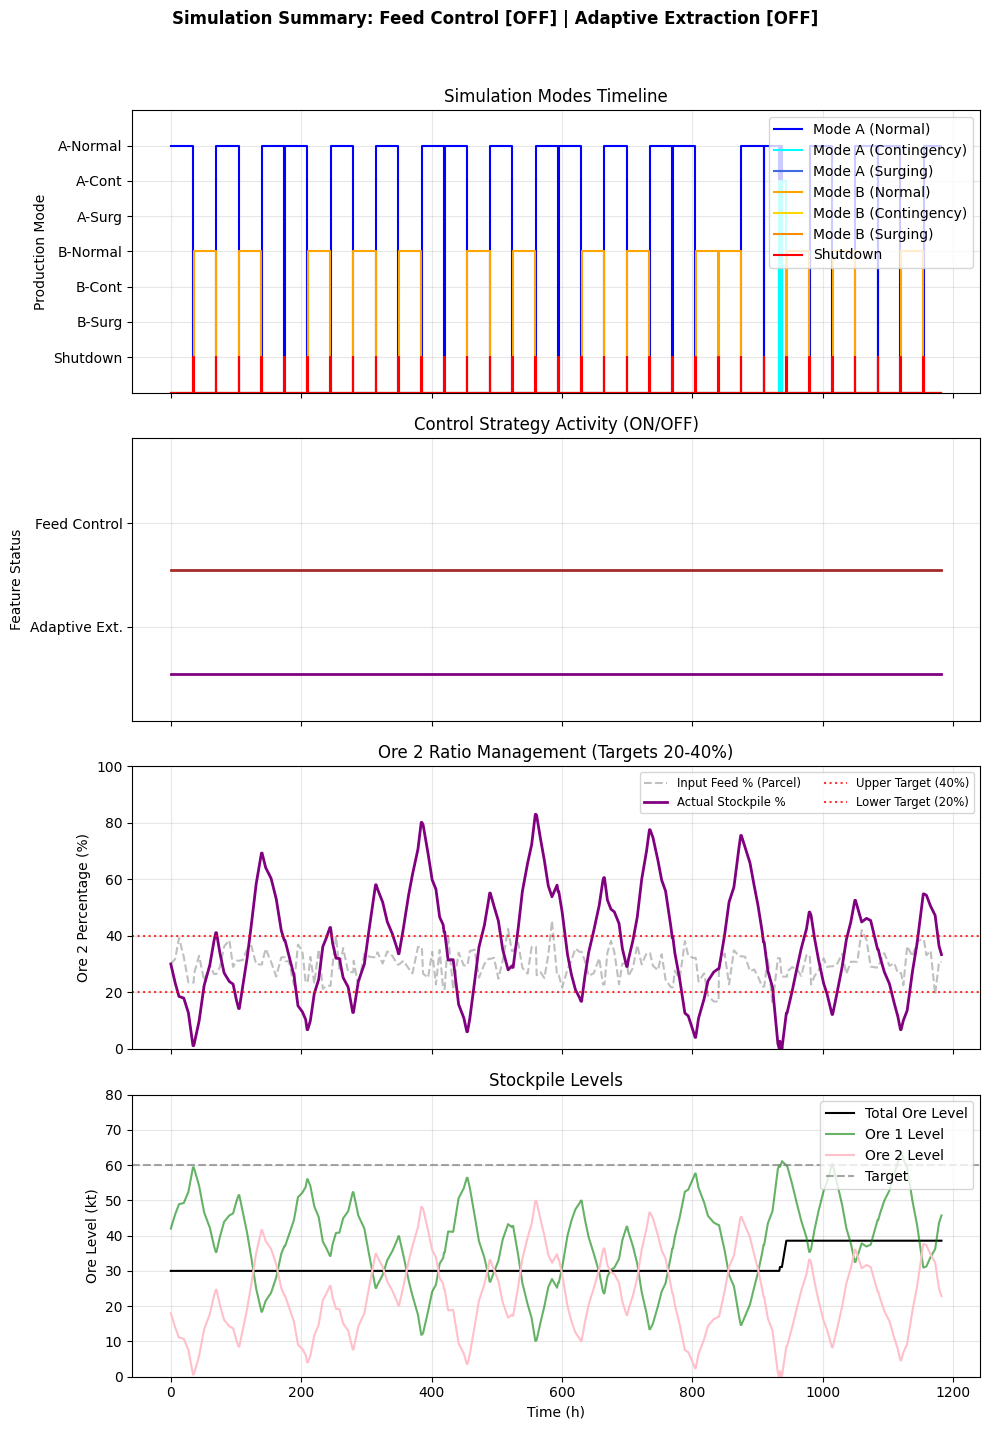

In [8]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

# Import your newly finished class!
from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0
    controlVariable_StockUpperLimit: float = 60000.5  # Default to no deadband
    controlVariable_StockLowerLimit: float = 59999.5  # Default to no deadband

    # --- FIXES ---
    parameter_ExtractionGain: float = 0.01
    enable_feed_control: bool = True


# Initialize parameters
mining_params = MiningParameters()


# Initialize parameters
mining_params = MiningParameters()

Initializing Framework...
Starting simulation loop...
Iteration 100: TNOW = 514.18
Iteration 200: TNOW = 1019.91
Simulation terminated successfully at TNOW: 1185.46 days.
Execution Time: 0.4414 seconds.

--- Final Simulation Statistics ---
Total Throughput:             5,567.47 t/day
Time in Mode A:               48.76%
Time in Mode B:               48.46%
Time in Shutdown:             2.78%
Time in Mode A Contingency:   0.00%
Time in Mode B Contingency:   0.00%
-----------------------------------


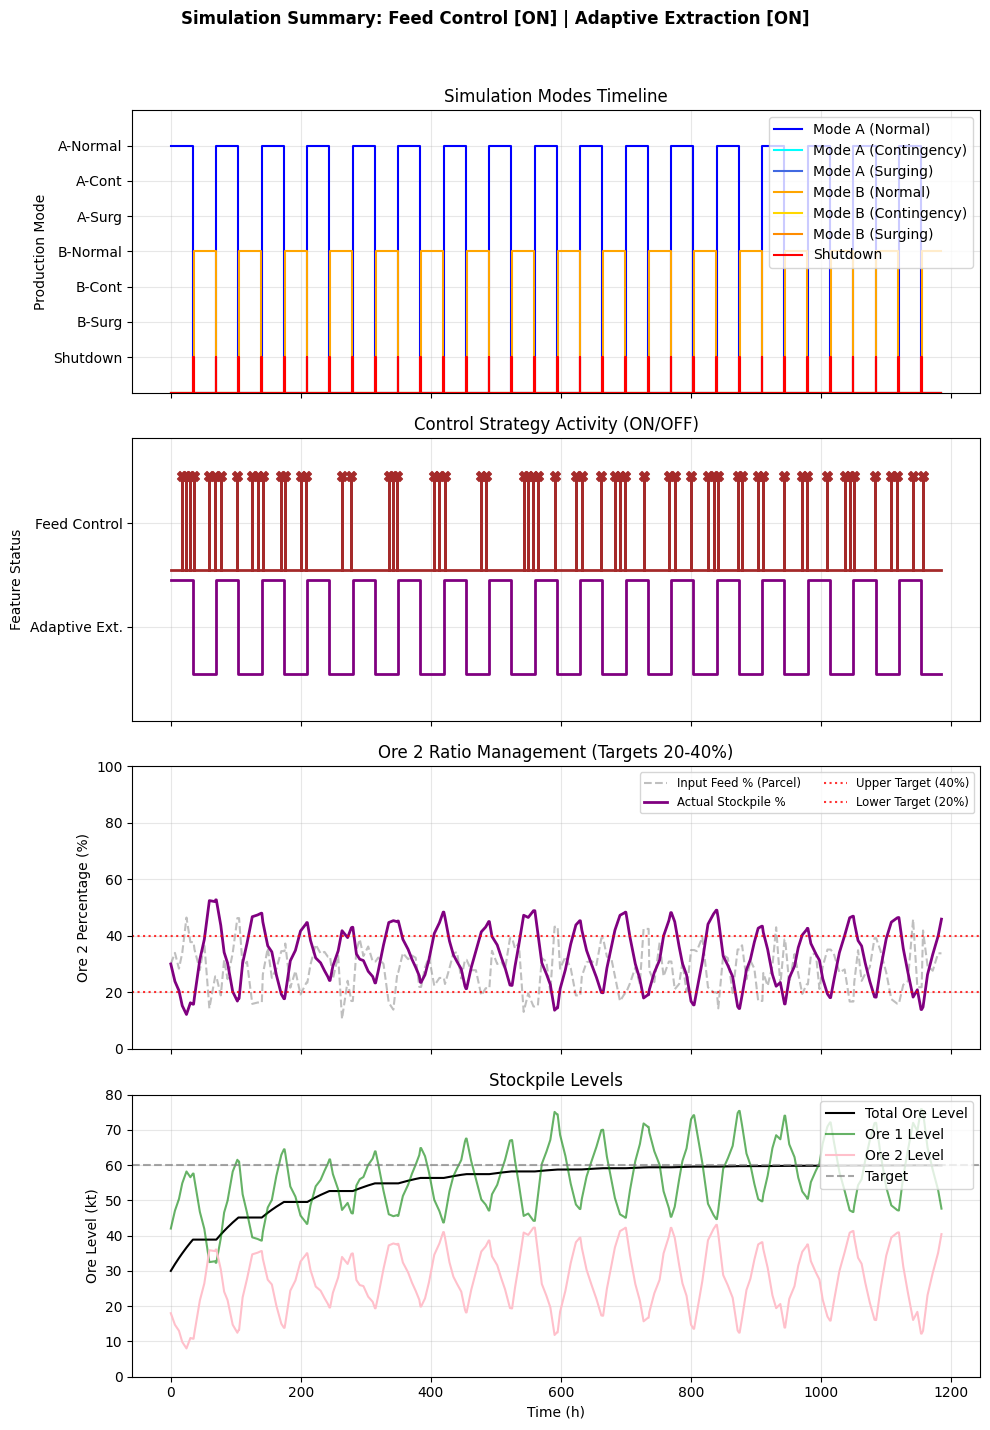

In [10]:
# Initialize Engine with decoupled parameters
print("Initializing Framework...")
model = DRSModel(parameters=mining_params)
model.load_configuration(arena_config)

# Run Simulation
print("Starting simulation loop...")
start_time = time.time()
model.run()
execution_time = time.time() - start_time

print(f"Simulation terminated successfully at TNOW: {model.TNOW:.2f} days.")
print(f"Execution Time: {execution_time:.4f} seconds.\n")

# Calculate Outputs
stats = model.calculate_statistics()
print("--- Final Simulation Statistics ---")
print(f"Total Throughput:             {stats.Throughput:,.2f} t/day")
print(f"Time in Mode A:               {stats.PortionOfTimeInModeA * 100:.2f}%")
print(f"Time in Mode B:               {stats.PortionOfTimeInModeB * 100:.2f}%")
print(f"Time in Shutdown:             {stats.PortionOfTimeInShutdown * 100:.2f}%")
print(
    f"Time in Mode A Contingency:   {stats.PortionOfTimeInModeAContingency * 100:.2f}%"
)
print(
    f"Time in Mode B Contingency:   {stats.PortionOfTimeInModeBContingency * 100:.2f}%"
)
print("-----------------------------------")

# Render Plots
model.plot_results()

In [11]:
import numpy as np
import pandas as pd
from model.drs_model import DRSModel
import itertools


def run_ablation_trial(
    use_feed_control: bool,
    use_adaptive: bool,
    config_dict: dict,
    num_replications: int = 3,
):
    # 1. Define the baseline parameters
    params = MiningParameters()

    # 2. Apply Ablation Logic (Parameter Nullification)
    params.enable_feed_control = use_feed_control

    if use_adaptive:
        params.parameter_ExtractionGain = 0.08
        params.parameter_MaxExtraction = 7200.0
        params.parameter_MinExtraction = 1000.0
    else:
        params.parameter_ExtractionGain = 0.0

    # Ensure no hysteresis by default in ablation trials
    params.controlVariable_StockUpperLimit = 60000.5
    params.controlVariable_StockLowerLimit = 59999.5

    throughputs = []
    switches_list = []
    shutdowns = []

    for replication_seed in range(num_replications):
        model = DRSModel(parameters=params)
        model.load_configuration(config_dict)
        np.random.seed(replication_seed)
        model.run()

        rate_history = np.array(model.history_rate_config)
        num_switches = np.sum(np.diff(rate_history) != 0)
        switches_list.append(num_switches)

        stats = model.calculate_statistics()
        throughputs.append(stats.Throughput)
        shutdowns.append(stats.PortionOfTimeInShutdown * 100)

    return {
        "Feed Control": "ON" if use_feed_control else "OFF",
        "Adaptive Extraction": "ON" if use_adaptive else "OFF",
        "Throughput (t/day)": round(np.mean(throughputs), 2),
        "Mode Switches": int(np.mean(switches_list)),
        "Time in Shutdown (%)": round(np.mean(shutdowns), 2),
    }

    # 1. Define the baseline parameters
    params = MiningParameters()

    # 2. Apply Ablation Logic (Parameter Nullification)
    params.enable_feed_control = use_feed_control

    if use_adaptive:
        params.parameter_ExtractionGain = 0.08
        params.parameter_MaxExtraction = 7200.0
        params.parameter_MinExtraction = 1000.0
    else:
        params.parameter_ExtractionGain = 0.0  # Nullifies the proportional controller

    if use_hysteresis:
        params.controlVariable_StockUpperLimit = 65000.0
        params.controlVariable_StockLowerLimit = 50000.0
    else:
        # Nullifies the deadband, forcing immediate switching at 60k
        params.controlVariable_StockUpperLimit = 60000.5
        params.controlVariable_StockLowerLimit = 59999.5

    # Lists to store the outcomes of each replication
    throughputs = []
    switches_list = []
    shutdowns = []

    # 3. Run Replications
    for replication_seed in range(num_replications):
        model = DRSModel(parameters=params)
        model.load_configuration(config_dict)

        # Lock the RNG for this specific replication to ensure reproducibility
        np.random.seed(replication_seed)

        model.run()

        # 4. Calculate metrics for this specific run
        rate_history = np.array(model.history_rate_config)
        num_switches = np.sum(np.diff(rate_history) != 0)
        switches_list.append(num_switches)

        stats = model.calculate_statistics()
        throughputs.append(stats.Throughput)
        shutdowns.append(stats.PortionOfTimeInShutdown * 100)

    # 5. Return the averaged results across all replications
    return {
        "Feed Control": "ON" if use_feed_control else "OFF",
        "Adaptive Extraction": "ON" if use_adaptive else "OFF",
        "Hysteresis": "ON" if use_hysteresis else "OFF",
        "Throughput (t/day)": round(np.mean(throughputs), 2),
        "Mode Switches": int(np.mean(switches_list)),
        "Time in Shutdown (%)": round(np.mean(shutdowns), 2),
    }

In [12]:
print("Running Ablation Study (4 combinations)...")
results = []

# itertools.product generates all True/False combinations
toggles = [False, True]
for feed, adapt in itertools.product(toggles, toggles):
    print(f"Running -> Feed: {feed} | Adapt: {adapt}")
    trial_result = run_ablation_trial(feed, adapt, arena_config)
    results.append(trial_result)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(
    by="Throughput (t/day)", ascending=False
).reset_index(drop=True)
display(df_results)

Running Ablation Study (4 combinations)...
Running -> Feed: False | Adapt: False
Iteration 100: TNOW = 519.73
Iteration 200: TNOW = 1006.95
Iteration 100: TNOW = 490.00
Iteration 200: TNOW = 999.98
Iteration 100: TNOW = 490.00
Iteration 200: TNOW = 1009.14
Running -> Feed: False | Adapt: True
Iteration 100: TNOW = 491.92
Iteration 200: TNOW = 1006.44
Iteration 100: TNOW = 501.84
Iteration 200: TNOW = 1015.00
Iteration 100: TNOW = 508.52
Iteration 200: TNOW = 1015.00
Running -> Feed: True | Adapt: False
Iteration 100: TNOW = 523.13
Iteration 200: TNOW = 1026.47
Iteration 100: TNOW = 510.24
Iteration 200: TNOW = 1020.29
Iteration 100: TNOW = 515.07
Iteration 200: TNOW = 1020.18
Running -> Feed: True | Adapt: True
Iteration 100: TNOW = 518.13
Iteration 200: TNOW = 1020.92
Iteration 100: TNOW = 501.84
Iteration 200: TNOW = 1015.00
Iteration 100: TNOW = 510.07
Iteration 200: TNOW = 1015.00


,Feed Control,Adaptive Extraction,Throughput (t/day),Mode Switches,Time in Shutdown (%)
0,OFF,ON,5606.16,67,2.80
1,ON,ON,5587.85,66,2.79
2,OFF,OFF,5578.46,70,2.79
3,ON,OFF,5537.84,68,2.85


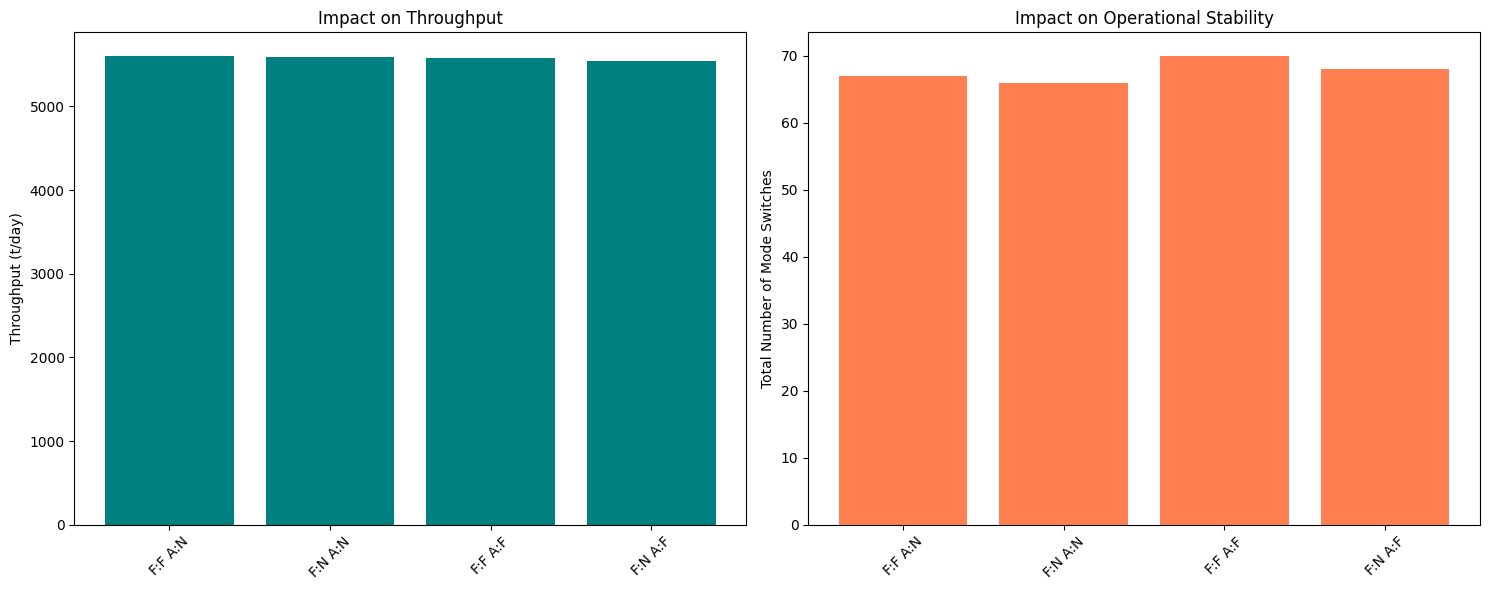

In [13]:
import matplotlib.pyplot as plt

# Create labels for the X-axis (e.g., "F:N A:F")
labels = df_results.apply(
    lambda row: f"F:{row['Feed Control'][1]} A:{row['Adaptive Extraction'][1]}",
    axis=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Throughput Comparison
ax1.bar(labels, df_results["Throughput (t/day)"], color="teal")
ax1.set_title("Impact on Throughput")
ax1.set_ylabel("Throughput (t/day)")
ax1.tick_params(axis="x", rotation=45)

# Plot 2: Stability (Mode Switches) Comparison
ax2.bar(labels, df_results["Mode Switches"], color="coral")
ax2.set_title("Impact on Operational Stability")
ax2.set_ylabel("Total Number of Mode Switches")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

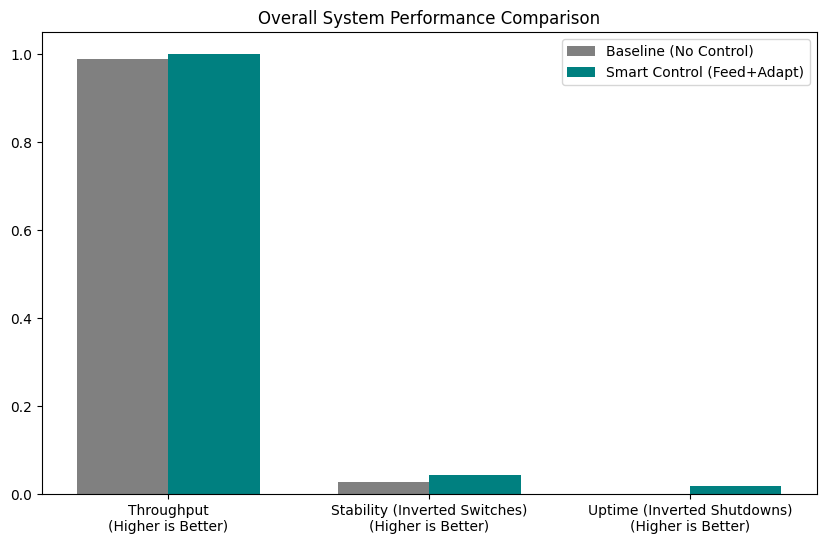

In [14]:
# Assuming you have the df_results from the ablation study
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize data for comparison
df_normalized = df_results.copy()
for col in ["Throughput (t/day)", "Mode Switches", "Time in Shutdown (%)"]:
    df_normalized[col] = df_normalized[col] / df_normalized[col].max()

# Plot the optimal run (Feed + Adaptive ON) vs the Baseline (Both OFF)
baseline = df_normalized.iloc[-1]  # Bottom of sorted list
optimal = df_normalized.iloc[0]  # Top of sorted list (Best Throughput)

x = np.arange(3)
width = 0.35

ax.bar(
    x - width / 2,
    [
        baseline["Throughput (t/day)"],
        1 - baseline["Mode Switches"],
        1 - baseline["Time in Shutdown (%)"],
    ],
    width,
    label="Baseline (No Control)",
    color="gray",
)

ax.bar(
    x + width / 2,
    [
        optimal["Throughput (t/day)"],
        1 - optimal["Mode Switches"],
        1 - optimal["Time in Shutdown (%)"],
    ],
    width,
    label="Smart Control (Feed+Adapt)",
    color="teal",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Throughput\n(Higher is Better)",
        "Stability (Inverted Switches)\n(Higher is Better)",
        "Uptime (Inverted Shutdowns)\n(Higher is Better)",
    ]
)
ax.set_title("Overall System Performance Comparison")
ax.legend()

plt.show()